# 02 — Feature Engineering
**Projet LendingClub | Membre 1**

| Étape | Contenu |
|---|---|
| 1 | Chargement données nettoyées |
| 2 | Ratios financiers |
| 3 | Variables d'interaction |
| 4 | Variable durée (pour Survival Analysis) |
| 5 | Target Encoding ★ (hors cours) |
| 6 | Analyse des nouvelles features |
| 7 | Sauvegarde |

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

PROCESSED = '../data/processed'
os.makedirs(PROCESSED, exist_ok=True)
print('✅ Imports OK')

✅ Imports OK


## 1. Chargement des données nettoyées

In [2]:
df = pd.read_parquet(f'{PROCESSED}/lending_clean.parquet')
print(f'✅ Chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'Taux de défaut : {df["target"].mean()*100:.1f}%')
display(df.head(3))

✅ Chargé : 1,345,310 lignes × 115 colonnes
Taux de défaut : 20.0%


,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,...,num_tl_90g_dpd_24m_was_nan,num_tl_op_past_12m_was_nan,pct_tl_nvr_dlq_was_nan,percent_bc_gt_75_was_nan,pub_rec_bankruptcies_was_nan,tax_liens_was_nan,tot_hi_cred_lim_was_nan,total_bal_ex_mort_was_nan,total_bc_limit_was_nan,total_il_high_credit_limit_was_nan
0,3600.0,3600.0,36.0,13.99,123.03,C,C4,leadman,10.0,MORTGAGE,...,0,0,0,0,0,0,0,0,0,0
1,24700.0,24700.0,36.0,11.99,820.28,C,C1,Engineer,10.0,MORTGAGE,...,0,0,0,0,0,0,0,0,0,0
2,20000.0,20000.0,60.0,10.78,432.66,B,B4,truck driver,10.0,MORTGAGE,...,0,0,0,0,0,0,0,0,0,0


## 2. Ratios financiers

Ces ratios capturent la **capacité de remboursement** de l'emprunteur,
une information que les variables brutes n'expriment pas directement.

In [3]:
# ── loan_to_income ────────────────────────────────────────────────────
# Ratio montant du prêt / revenu annuel → capacité d'endettement
df['loan_to_income'] = df['loan_amnt'] / df['annual_inc'].replace(0, np.nan)

# ── installment_to_income ─────────────────────────────────────────────
# Mensualité / revenu mensuel → charge de remboursement mensuelle
df['installment_to_income'] = df['installment'] / (df['annual_inc'].replace(0, np.nan) / 12)

# ── credit_history_years ──────────────────────────────────────────────
# Ancienneté du crédit en années → expérience financière
if 'issue_d' in df.columns and 'earliest_cr_line' in df.columns:
    df['credit_history_years'] = (
        (df['issue_d'] - df['earliest_cr_line']).dt.days / 365.25
    ).clip(lower=0)
    print(f'✅ credit_history_years | moy={df["credit_history_years"].mean():.1f} ans')

# ── revol_util_safe ───────────────────────────────────────────────────
# Taux d'utilisation du crédit revolving (borné 0-100)
if 'revol_util' in df.columns:
    df['revol_util'] = df['revol_util'].clip(0, 100)

# ── credit_util ───────────────────────────────────────────────────────
# Montant revolving / (revolving + prêt demandé)
df['credit_util'] = (
    df['revol_bal'] / (df['revol_bal'] + df['loan_amnt']).replace(0, np.nan)
).clip(0, 1)

print('✅ Ratios financiers créés :')
for col in ['loan_to_income','installment_to_income','credit_util']:
    print(f'   {col:<30} moy={df[col].mean():.4f}  std={df[col].std():.4f}')

✅ credit_history_years | moy=16.3 ans
✅ Ratios financiers créés :
   loan_to_income                 moy=0.3974  std=70.8287
   installment_to_income          moy=0.1424  std=23.6439
   credit_util                    moy=0.4745  std=0.1885


## 3. Variables d'interaction

On crée des termes d'interaction entre features importantes pour
capturer des effets combinés (ex: taux élevé ET longue durée = risque maximal).

In [4]:
# ── int_rate_x_term ───────────────────────────────────────────────────
# Coût total du prêt (approximatif) = taux × durée
df['int_rate_x_term'] = df['int_rate'] * df['term']

# ── dti_x_revol ───────────────────────────────────────────────────────
# Endettement global × utilisation revolving → double pression financière
if 'dti' in df.columns and 'revol_util' in df.columns:
    df['dti_x_revol'] = df['dti'] * df['revol_util']

# ── fico_x_grade ──────────────────────────────────────────────────────
# FICO score × grade → cohérence de la notation
if 'fico_range_low' in df.columns and 'grade' in df.columns:
    grade_map = {'A':1, 'B':2, 'C':3, 'D':4, 'E':5, 'F':6, 'G':7}
    df['grade_num'] = df['grade'].map(grade_map)
    
    df['fico_x_grade'] = df['fico_range_low'] * df['grade_num']

# ── loan_to_income_x_dti ──────────────────────────────────────────────
if 'dti' in df.columns:
    df['loan_income_x_dti'] = df['loan_to_income'] * df['dti']

print("✅ Variables d'interaction créées :")
for col in ['int_rate_x_term','dti_x_revol','fico_x_grade','loan_income_x_dti']:
    if col in df.columns:
        print(f'   {col:<30} moy={df[col].mean():.2f}')

✅ Variables d'interaction créées :
   int_rate_x_term                moy=573.72
   dti_x_revol                    moy=985.66
   fico_x_grade                   moy=1894.82
   loan_income_x_dti              moy=10.58


## 4. Variable durée — pour Survival Analysis (Membre 2)

Cette variable est essentielle pour l'analyse de survie :
elle indique combien de mois le prêt a duré avant la fin (défaut ou remboursement).

In [5]:
# duration_months = nombre de mois entre l'émission et le dernier paiement
# Utilisé uniquement pour survival analysis — PAS pour la classification
# (last_pymnt_d serait du leakage pour la classification → sauvegardé séparément)

# On utilise term comme proxy de durée pour la classification
# Pour survival : le membre 2 utilisera une version spéciale du dataset

# issue_year / issue_month → tendances temporelles
if 'issue_d' in df.columns:
    df['issue_year']  = df['issue_d'].dt.year
    df['issue_month'] = df['issue_d'].dt.month
    print(f'✅ issue_year  : {df["issue_year"].min()} → {df["issue_year"].max()}')
    print(f'✅ issue_month : 1 → 12')

# Supprimer les colonnes datetime maintenant (non compatibles avec sklearn)
date_cols = df.select_dtypes(include='datetime64').columns.tolist()
df.drop(columns=date_cols, inplace=True)
print(f'\nColonnes datetime supprimées : {date_cols}')
print(f'Shape : {df.shape}')

✅ issue_year  : 2007 → 2018
✅ issue_month : 1 → 12

Colonnes datetime supprimées : ['issue_d', 'earliest_cr_line']
Shape : (1345310, 124)


## 5. Target Encoding ★ (hors cours)

**Principe :** encoder une variable catégorielle par le taux de défaut moyen de chaque modalité.
Ex: `purpose = 'small_business'` → taux de défaut = 23.4% → encodé comme 0.234

**Avantage vs get_dummies :** pas d'explosion du nombre de colonnes (addr_state a 50 modalités).

**Précaution :** on utilise la validation croisée pour éviter le data leakage lors de l'encodage.

In [6]:
from sklearn.model_selection import KFold

def target_encode_cv(df, col, target_col='target', n_splits=5, smoothing=10):
    """
    Target Encoding avec validation croisée pour éviter l'overfitting.
    smoothing : régularisation (mélange entre moyenne globale et moyenne locale)
    """
    global_mean = df[target_col].mean()
    encoded     = pd.Series(index=df.index, dtype=float)
    kf          = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    for train_idx, val_idx in kf.split(df):
        train_df  = df.iloc[train_idx]
        # Calcul de la moyenne et du count par modalité sur le fold d'entraînement
        stats     = train_df.groupby(col)[target_col].agg(['mean','count'])
        # Formule de smoothing : mélange entre moyenne locale et globale
        smooth    = (stats['count'] * stats['mean'] + smoothing * global_mean) / (stats['count'] + smoothing)
        encoded.iloc[val_idx] = df[col].iloc[val_idx].map(smooth).fillna(global_mean)

    return encoded

# Colonnes à encoder par target encoding
HIGH_CARDINALITY = ['purpose','addr_state','home_ownership','verification_status']
high_card_present = [c for c in HIGH_CARDINALITY if c in df.columns]

print('Target Encoding en cours ...')
te_stats = {}
for col in high_card_present:
    n_modal = df[col].nunique()
    df[f'{col}_te'] = target_encode_cv(df, col)
    mean_rate = df[f'{col}_te'].mean()
    te_stats[col] = (n_modal, mean_rate)
    print(f'  ✅ {col:<25} {n_modal:>3} modalités → {col}_te  (moy défaut={mean_rate:.3f})')

Target Encoding en cours ...
  ✅ purpose                    14 modalités → purpose_te  (moy défaut=0.200)
  ✅ addr_state                 51 modalités → addr_state_te  (moy défaut=0.200)
  ✅ home_ownership              6 modalités → home_ownership_te  (moy défaut=0.200)
  ✅ verification_status         3 modalités → verification_status_te  (moy défaut=0.200)


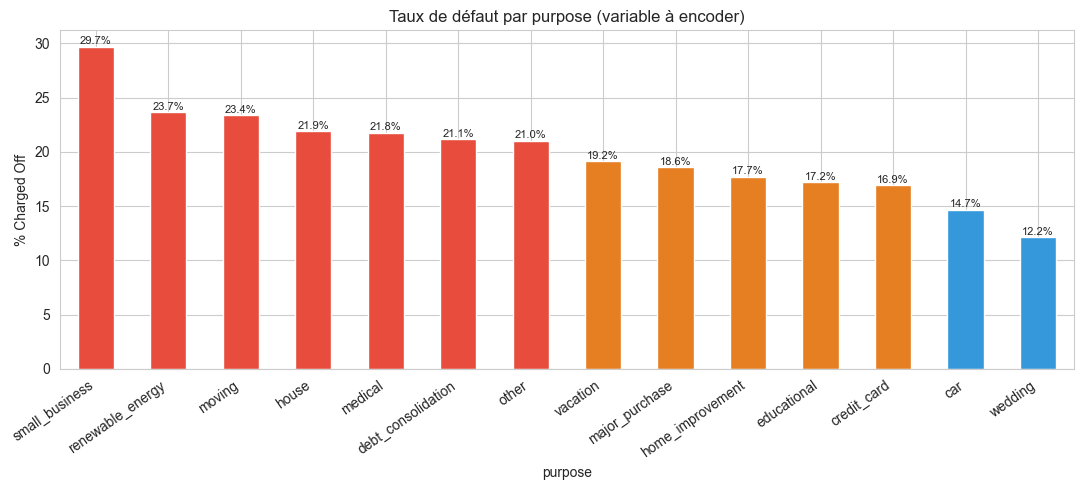

In [7]:
# Visualisation : taux de défaut par purpose
if 'purpose' in df.columns:
    fig, ax = plt.subplots(figsize=(11,5))
    rate = df.groupby('purpose')['target'].mean().sort_values(ascending=False) * 100
    colors = ['#e74c3c' if x>20 else '#e67e22' if x>15 else '#3498db' for x in rate.values]
    rate.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
    ax.set_title('Taux de défaut par purpose (variable à encoder)')
    ax.set_ylabel('% Charged Off')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%',(p.get_x()+p.get_width()/2, p.get_height()+0.2),
                    ha='center', fontsize=8)
    plt.tight_layout()
    plt.savefig(f'{PROCESSED}/06_default_by_purpose.png', dpi=130)
    plt.show()

## 6. Analyse des nouvelles features

Corrélation Pearson des nouvelles features avec target :
int_rate_x_term          0.260619
fico_x_grade             0.258521
dti_x_revol              0.092785
credit_util             -0.060849
credit_history_years    -0.033418
loan_to_income          -0.000281
installment_to_income   -0.000280
loan_income_x_dti       -0.000028


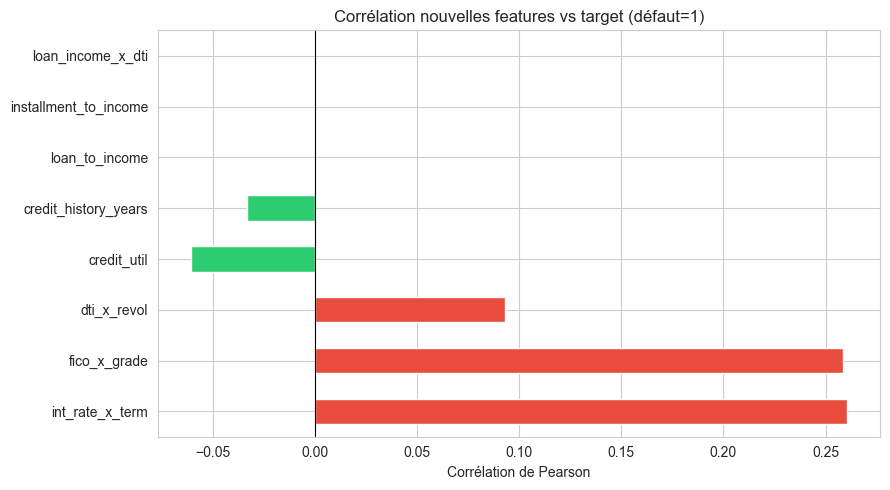

In [8]:
# Corrélation des nouvelles features avec la target
new_features = [
    'loan_to_income','installment_to_income','credit_util',
    'int_rate_x_term','dti_x_revol','fico_x_grade',
    'loan_income_x_dti',
]
if 'credit_history_years' in df.columns:
    new_features.append('credit_history_years')

new_features = [c for c in new_features if c in df.columns]

corr = df[new_features + ['target']].corr()['target'].drop('target').sort_values(key=abs, ascending=False)
print('Corrélation Pearson des nouvelles features avec target :')
print(corr.to_string())

fig, ax = plt.subplots(figsize=(9,5))
colors = ['#e74c3c' if v>0 else '#2ecc71' for v in corr.values]
corr.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Corrélation nouvelles features vs target (défaut=1)', fontsize=12)
ax.set_xlabel('Corrélation de Pearson')
plt.tight_layout()
plt.savefig(f'{PROCESSED}/07_new_features_corr.png', dpi=130)
plt.show()

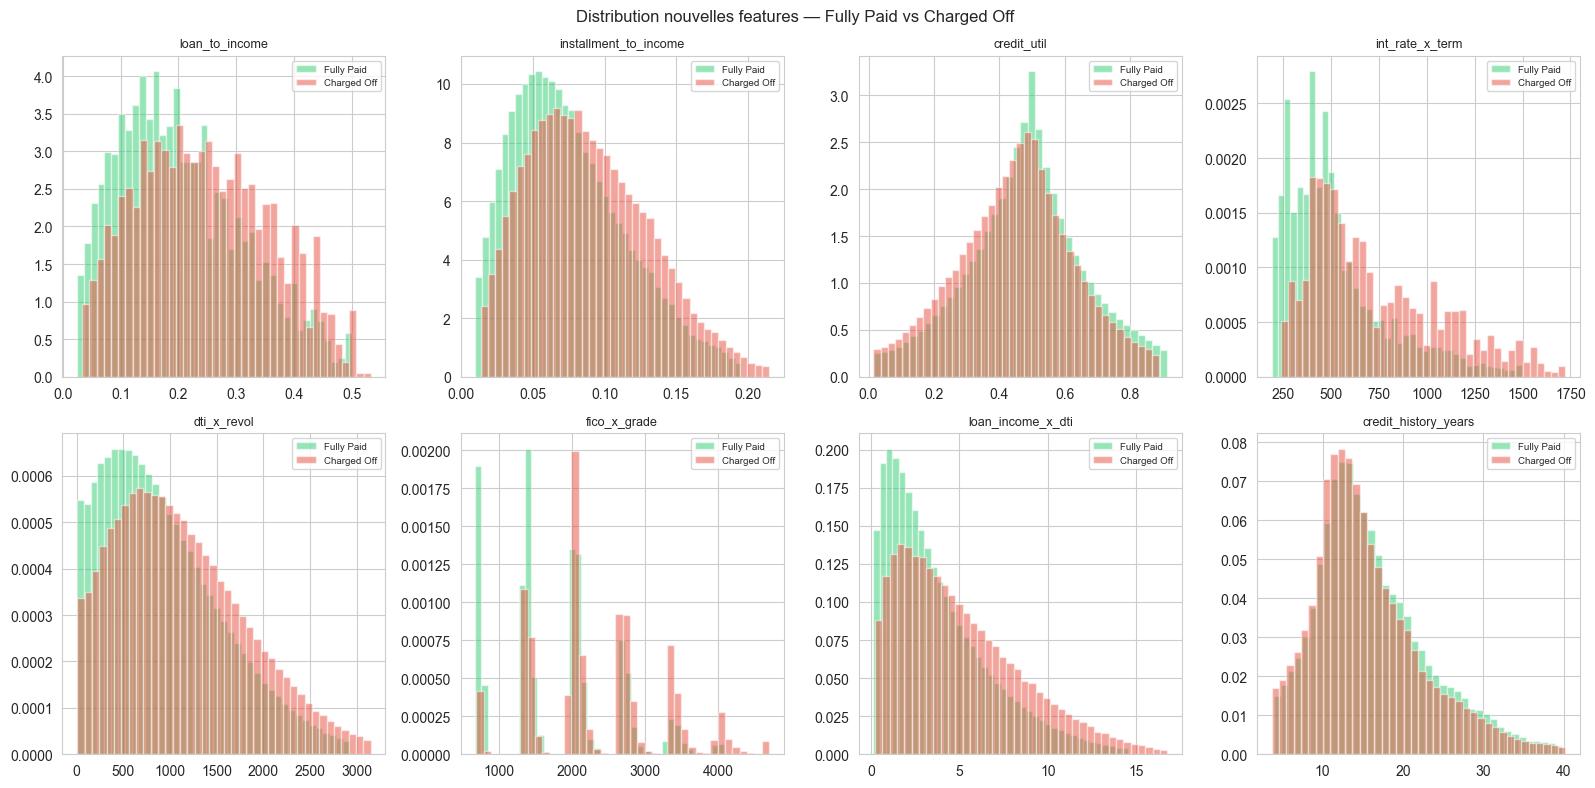

In [9]:
# Distribution des nouvelles features par classe
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(new_features[:8]):
    ax = axes[i]
    for val, label, color in [(0,'Fully Paid','#2ecc71'),(1,'Charged Off','#e74c3c')]:
        data = df[df['target']==val][col].dropna()
        data = data[data.between(data.quantile(0.01), data.quantile(0.99))]
        ax.hist(data, bins=40, alpha=0.5, label=label, color=color, density=True)
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)

for j in range(len(new_features[:8]), len(axes)): axes[j].set_visible(False)
plt.suptitle('Distribution nouvelles features — Fully Paid vs Charged Off', fontsize=12)
plt.tight_layout()
plt.savefig(f'{PROCESSED}/08_new_features_dist.png', dpi=130)
plt.show()

In [10]:
# Résumé de toutes les features créées
all_new = new_features + [f'{c}_te' for c in high_card_present if f'{c}_te' in df.columns]
if 'issue_year' in df.columns:  all_new += ['issue_year','issue_month']

print(f'\nTotal nouvelles features créées : {len(all_new)}')
print('Shape finale du dataset :', df.shape)


Total nouvelles features créées : 14
Shape finale du dataset : (1345310, 128)


## 7. Sauvegarde

In [11]:
out_pq  = f'{PROCESSED}/lending_features.parquet'
out_csv = f'{PROCESSED}/lending_features.csv'
df.to_parquet(out_pq, index=False)
df.to_csv(out_csv, index=False)

print(f'✅ Parquet : {out_pq}  ({os.path.getsize(out_pq)/1e6:.1f} MB)')
print(f'✅ CSV     : {out_csv}  ({os.path.getsize(out_csv)/1e6:.1f} MB)')
print(f'   Shape  : {df.shape[0]:,} × {df.shape[1]}')
print('\n→ Prochain : 03_pipeline.ipynb')

✅ Parquet : ../data/processed/lending_features.parquet  (191.0 MB)
✅ CSV     : ../data/processed/lending_features.csv  (965.8 MB)
   Shape  : 1,345,310 × 128

→ Prochain : 03_pipeline.ipynb
